# Variational Model Capacity Benchmark

Sweep small capacity settings for VQC, QCNN, and VQR, then compare against simple classical references. The defaults are smoke-scale; raise `steps`, `seeds`, and `n_samples` for production benchmark runs.

In [1]:
from pathlib import Path
import sys
from time import perf_counter

repo_root = Path.cwd().resolve()
if not (repo_root / "src" / "qml").exists():
    repo_root = next(
        (parent for parent in repo_root.parents if (parent / "src" / "qml").exists()),
        repo_root,
    )
package_root = repo_root / "src"
if str(package_root) not in sys.path:
    sys.path.insert(0, str(package_root))

In [2]:
from qml.classical_baselines import run_logistic_classifier, run_ridge_regression
from qml.classifiers import run_vqc
from qml.qcnn import run_qcnn
from qml.regression import run_vqr
from qml.reporting import print_table
import matplotlib.pyplot as plt

In [3]:
CONFIG = {
    "seeds": [0],
    "n_samples": 32,
    "classification_dataset": "moons",
    "regression_dataset": "sine",
    "noise": 0.1,
    "test_size": 0.25,
}

vqc_grid = [{"n_layers": 1, "steps": 4}, {"n_layers": 2, "steps": 4}]
qcnn_grid = [{"steps": 4}, {"steps": 8}]
vqr_grid = [{"n_layers": 1, "steps": 5}, {"n_layers": 2, "steps": 5}]

In [4]:
def timed_call(fn, **kwargs):
    start = perf_counter()
    result = fn(**kwargs)
    return result, perf_counter() - start


def mean(values):
    return sum(values) / len(values)


def aggregate(rows, group_keys, metric_keys):
    groups = {}
    for row in rows:
        key = tuple(row[name] for name in group_keys)
        groups.setdefault(key, []).append(row)

    aggregated = []
    for key, group_rows in groups.items():
        record = dict(zip(group_keys, key, strict=True))
        for metric in metric_keys:
            record[metric] = mean([float(row[metric]) for row in group_rows])
        record["runtime_s"] = mean([float(row["runtime_s"]) for row in group_rows])
        record["runs"] = len(group_rows)
        aggregated.append(record)
    return aggregated

## Classification Capacity

In [5]:
classification_rows = []

for seed in CONFIG["seeds"]:
    baseline, runtime = timed_call(
        run_logistic_classifier,
        dataset=CONFIG["classification_dataset"],
        seed=seed,
        n_samples=CONFIG["n_samples"],
        noise=CONFIG["noise"],
        test_size=CONFIG["test_size"],
        plot=False,
        save=False,
    )
    classification_rows.append({"model": "logistic_regression", "capacity": "reference", "seed": seed, "test_accuracy": baseline["test_accuracy"], "runtime_s": runtime})

    for config in vqc_grid:
        result, runtime = timed_call(
            run_vqc,
            dataset=CONFIG["classification_dataset"],
            seed=seed,
            n_samples=CONFIG["n_samples"],
            noise=CONFIG["noise"],
            test_size=CONFIG["test_size"],
            step_size=0.1,
            plot=False,
            save=False,
            **config,
        )
        classification_rows.append({"model": "vqc", "capacity": str(config), "seed": seed, "test_accuracy": result["test_accuracy"], "runtime_s": runtime})

    for config in qcnn_grid:
        result, runtime = timed_call(
            run_qcnn,
            dataset=CONFIG["classification_dataset"],
            seed=seed,
            n_samples=CONFIG["n_samples"],
            noise=CONFIG["noise"],
            test_size=CONFIG["test_size"],
            step_size=0.1,
            plot=False,
            save=False,
            **config,
        )
        classification_rows.append({"model": "qcnn", "capacity": str(config), "seed": seed, "test_accuracy": result["test_accuracy"], "runtime_s": runtime})

classification_summary = aggregate(classification_rows, ["model", "capacity"], ["test_accuracy"])
print_table(sorted(classification_summary, key=lambda row: row["test_accuracy"], reverse=True), title="Classification capacity summary")

Classification capacity summary
+---------------------+-----------------------------+---------------+-----------+------+
| model               | capacity                    | test_accuracy | runtime_s | runs |
+---------------------+-----------------------------+---------------+-----------+------+
| qcnn                | {'steps': 8}                | 0.875         | 10.8415   | 1    |
| logistic_regression | reference                   | 0.75          | 0.012237  | 1    |
| qcnn                | {'steps': 4}                | 0.625         | 5.71036   | 1    |
| vqc                 | {'n_layers': 1, 'steps': 4} | 0.375         | 0.756289  | 1    |
| vqc                 | {'n_layers': 2, 'steps': 4} | 0.375         | 1.50935   | 1    |
+---------------------+-----------------------------+---------------+-----------+------+



## Classification Capacity Plot

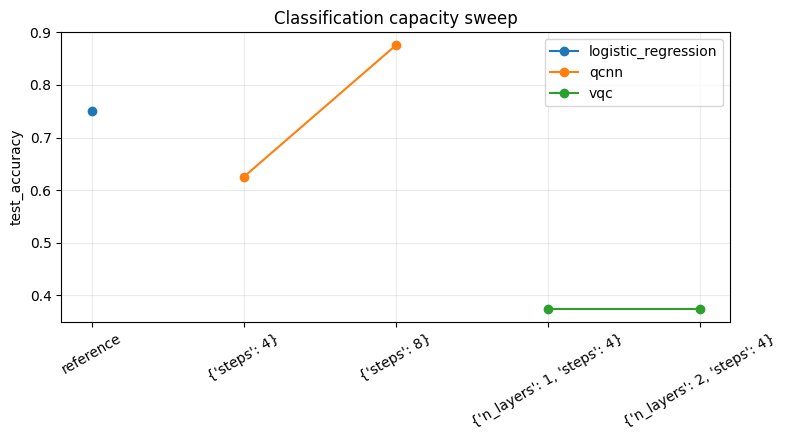

In [6]:

fig, ax = plt.subplots(figsize=(8, 4.5))
for model in sorted({row["model"] for row in classification_summary}):
    rows = [row for row in classification_summary if row["model"] == model]
    ax.plot([row["capacity"] for row in rows], [row["test_accuracy"] for row in rows], marker="o", label=model)
ax.set_title("Classification capacity sweep")
ax.set_ylabel("test_accuracy")
ax.tick_params(axis="x", rotation=30)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()


## Regression Capacity

In [7]:
regression_rows = []

for seed in CONFIG["seeds"]:
    baseline, runtime = timed_call(
        run_ridge_regression,
        dataset=CONFIG["regression_dataset"],
        seed=seed,
        n_samples=CONFIG["n_samples"],
        noise=CONFIG["noise"],
        test_size=CONFIG["test_size"],
        plot=False,
        save=False,
    )
    regression_rows.append({"model": "ridge_regression", "capacity": "reference", "seed": seed, "test_mse": baseline["test_mse"], "test_mae": baseline["test_mae"], "runtime_s": runtime})

    for config in vqr_grid:
        result, runtime = timed_call(
            run_vqr,
            dataset=CONFIG["regression_dataset"],
            seed=seed,
            n_samples=CONFIG["n_samples"],
            noise=CONFIG["noise"],
            test_size=CONFIG["test_size"],
            step_size=0.1,
            plot=False,
            save=False,
            **config,
        )
        regression_rows.append({"model": "vqr", "capacity": str(config), "seed": seed, "test_mse": result["test_mse"], "test_mae": result["test_mae"], "runtime_s": runtime})

regression_summary = aggregate(regression_rows, ["model", "capacity"], ["test_mse", "test_mae"])
print_table(sorted(regression_summary, key=lambda row: row["test_mse"]), title="Regression capacity summary")

Regression capacity summary
+------------------+-----------------------------+----------+----------+------------+------+
| model            | capacity                    | test_mse | test_mae | runtime_s  | runs |
+------------------+-----------------------------+----------+----------+------------+------+
| vqr              | {'n_layers': 1, 'steps': 5} | 0.131641 | 0.307639 | 0.732672   | 1    |
| vqr              | {'n_layers': 2, 'steps': 5} | 0.161685 | 0.370644 | 1.542      | 1    |
| ridge_regression | reference                   | 0.634695 | 0.70884  | 0.00462633 | 1    |
+------------------+-----------------------------+----------+----------+------------+------+



## Regression Capacity Plot

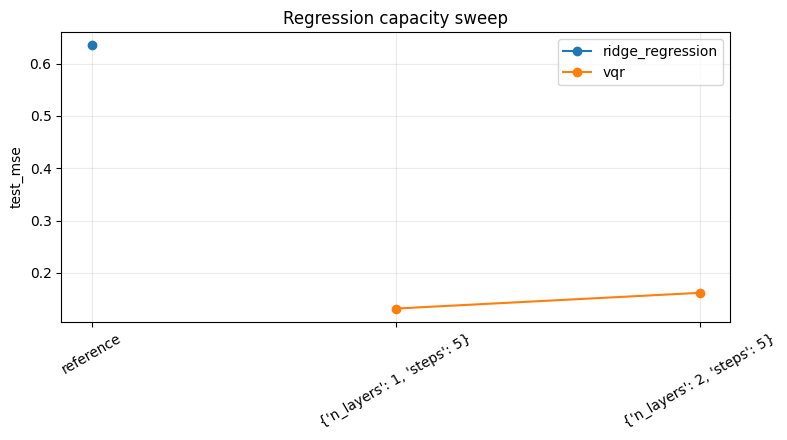

In [8]:

fig, ax = plt.subplots(figsize=(8, 4.5))
for model in sorted({row["model"] for row in regression_summary}):
    rows = [row for row in regression_summary if row["model"] == model]
    ax.plot([row["capacity"] for row in rows], [row["test_mse"] for row in rows], marker="o", label=model)
ax.set_title("Regression capacity sweep")
ax.set_ylabel("test_mse")
ax.tick_params(axis="x", rotation=30)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()
